# Métricas de Desempeño en HPC
## Universidad de Caldas 2026 - Ingeniería del Software en la Industria

Este notebook explora las métricas fundamentales de computación de alto rendimiento (HPC) usando ejemplos reales de la industria del software: Netflix, PyTorch, GitLab CI, Webpack, y otros.

**Objetivo**: Entender cómo paralelizar correctamente y cuándo es rentable.

## 🔧 Sección 0: Setup

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import time
import multiprocessing as mp
import warnings
from functools import reduce
import os

warnings.filterwarnings('ignore')
plt.style.use('dark_background')

# Paleta de colores profesional
PALETTE = {
    'red':'#EF4444',
    'blue':'#3B82F6',
    'green':'#10B981',
    'yellow':'#F4D35E',
    'orange':'#F59E0B',
    'teal':'#0D9488',
    'gray':'#475569',
    'purple':'#A78BFA',
    'pink':'#EC4899'
}

# Funciones fundamentales
def amdahl(f, p):
    """Ley de Amdahl: S(p) = 1 / (f + (1-f)/p)
    f: fracción no-paralelizable
    p: número de procesadores"""
    return 1 / (f + (1 - f) / p)

def gustafson(f, p):
    """Ley de Gustafson: S(p) = p - f*(p-1)
    f: fracción de tiempo serial en ejecución con 1 procesador
    p: número de procesadores"""
    return p - f * (p - 1)

print("✅ Setup completo. Librerías cargadas, funciones definidas.")
print(f"CPUs disponibles: {mp.cpu_count()}")

✅ Setup completo. Librerías cargadas, funciones definidas.
CPUs disponibles: 2


## ⏱️ Sección 1: Tiempo de Ejecución

### ¿Qué es el tiempo de ejecución?

**Tiempo de Ejecución (T)** es el tiempo total que un programa tarda en completarse, desde el inicio hasta el final.

**En la industria**: GitLab CI mide el tiempo de build y test para cada commit. Si un pipeline de integración continua tarda 2 minutos, ese es el tiempo de ejecución. Netflix necesita transcodificar videos en múltiples formatos y resoluciones—el tiempo que tarda todo el job es lo que nos importa.

**Variables clave**:
- `T_s`: Tiempo en un solo procesador (tiempo serial)
- `T_p`: Tiempo en p procesadores
- La diferencia `T_s - T_p` muestra cuánto ganamos con paralelización

In [ ]:
# Ejemplo: Medición de tiempo en GitLab CI
def gitlab_ci_job():
    """Simula un job de GitLab CI: compilar + tests
    (En realidad: operaciones CPU-bound de compresión de datos)"""
    result = 0
    for i in range(10**7):
        result += i * (i % 7) + (i ** 0.5)
    return result

# Medir con time.perf_counter() (más preciso que time.time())
print("🔍 Midiendo tiempo de ejecución...")
start = time.perf_counter()
result = gitlab_ci_job()
end = time.perf_counter()

T_s = end - start
print(f"Tiempo serial (T_s): {T_s:.3f} segundos")
print(f"Resultado: {result:.0f}")

🔍 Midiendo tiempo de ejecución...
Tiempo serial (T_s): 1.844 segundos
Resultado: 150021046849490


Simulando Webpack build con diferentes tamaños de bundle...
  Tamaño   1000000:  0.087s
  Tamaño   5000000:  0.637s
  Tamaño  10000000:  1.491s
  Tamaño  50000000:  5.072s
  Tamaño 100000000:  5.663s


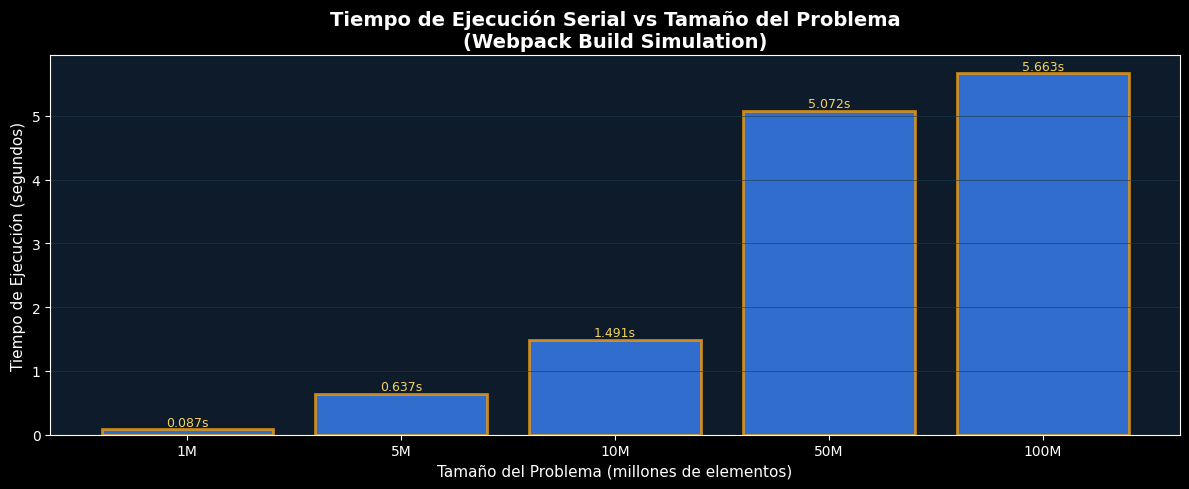


✓ Tiempo escala casi linealmente con tamaño del problema


In [ ]:
# Simulación: Tiempo de ejecución vs Tamaño del problema
# Escenario: Webpack compilando bundles de diferentes tamaños

problem_sizes = np.array([10**6, 5*10**6, 10**7, 5*10**7, 10**8])
times_serial = []

print("Simulando Webpack build con diferentes tamaños de bundle...")
for size in problem_sizes:
    start = time.perf_counter()
    _ = sum(i * (i % 7) for i in range(size))
    elapsed = time.perf_counter() - start
    times_serial.append(elapsed)
    print(f"  Tamaño {size:>9}: {elapsed:>6.3f}s")

# Graficar
fig, ax = plt.subplots(figsize=(12, 5))
ax.bar(range(len(problem_sizes)), times_serial, color=PALETTE['blue'], alpha=0.8, edgecolor=PALETTE['orange'], linewidth=2)
ax.set_xlabel('Tamaño del Problema (millones de elementos)', fontsize=11)
ax.set_ylabel('Tiempo de Ejecución (segundos)', fontsize=11)
ax.set_title('Tiempo de Ejecución Serial vs Tamaño del Problema\n(Webpack Build Simulation)', fontsize=14, fontweight='bold')
ax.set_xticks(range(len(problem_sizes)))
ax.set_xticklabels([f'{s/1e6:.0f}M' for s in problem_sizes])
ax.grid(axis='y', color='#1E3A4A', linewidth=0.7, alpha=0.6)
ax.set_facecolor('#0D1B2A')
for i, (size, t) in enumerate(zip(problem_sizes, times_serial)):
    ax.text(i, t + 0.01, f'{t:.3f}s', ha='center', va='bottom', fontsize=9, color=PALETTE['yellow'])

plt.tight_layout()
plt.show()

print(f"\n✓ Tiempo escala casi linealmente con tamaño del problema")

## 🚀 Sección 2: Speedup (Aceleración)

### ¿Qué es el Speedup?

**Speedup (S)** mide cuánto más rápido se ejecuta un programa en p procesadores comparado con un solo procesador:

$$S(p) = \frac{T_s}{T_p}$$

donde:
- `T_s`: tiempo en 1 procesador
- `T_p`: tiempo en p procesadores

**En la industria**: Webpack puede compilar un bundle en 120 segundos en una máquina (1 CPU). Si paraleliza el job en una máquina con 4 CPUs y tarda 45 segundos, el speedup es S = 120/45 = 2.67x.

**Speedup ideal**: Sería S(p) = p (si tuviéramos 4 CPUs, sería 4x más rápido). Pero nunca alcanzamos esto en la práctica.

In [ ]:
# Ejemplo: Webpack compilation speedup
print("📊 Ejemplo: Webpack Bundle Compilation\n")

T_s = 120  # segundos, una CPU
T_p_values = [120, 45, 32, 28, 27]  # tiempos en p=1,2,4,8,16 CPUs
procs = [1, 2, 4, 8, 16]

speedups = [T_s / T_p for T_p in T_p_values]
speedup_ideal = procs  # speedup ideal = p

print(f"T_s (tiempo serial): {T_s}s\n")
for p, T_p, S in zip(procs, T_p_values, speedups):
    efficiency = S / p
    print(f"p={p:2d} CPUs: T_p={T_p:3d}s, S={S:5.2f}x (Ideal: {p}x), E={efficiency:.1%}")

print(f"\n✓ Speedup > 1 significa que la paralelización ayuda")
print(f"✓ Speedup < p significa que hay overhead de paralelización")

📊 Ejemplo: Webpack Bundle Compilation

T_s (tiempo serial): 120s

p= 1 CPUs: T_p=120s, S= 1.00x (Ideal: 1x), E=100.0%
p= 2 CPUs: T_p= 45s, S= 2.67x (Ideal: 2x), E=133.3%
p= 4 CPUs: T_p= 32s, S= 3.75x (Ideal: 4x), E=93.8%
p= 8 CPUs: T_p= 28s, S= 4.29x (Ideal: 8x), E=53.6%
p=16 CPUs: T_p= 27s, S= 4.44x (Ideal: 16x), E=27.8%

✓ Speedup > 1 significa que la paralelización ayuda
✓ Speedup < p significa que hay overhead de paralelización


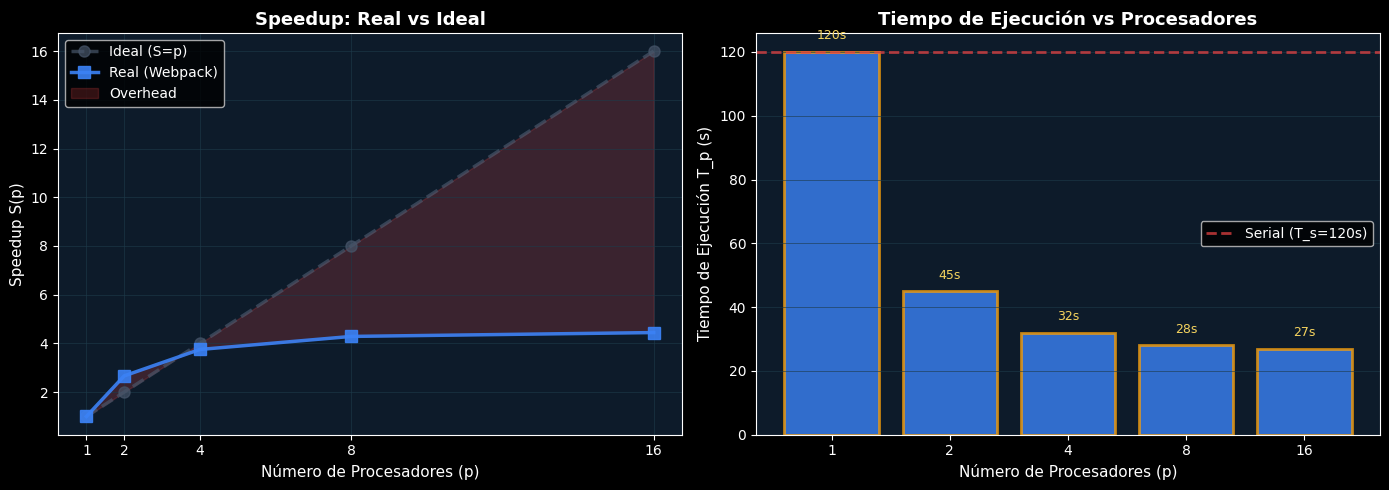

✓ El speedup diverge del ideal debido a overhead de sincronización y comunicación


In [ ]:
# Visualizar speedup: Real vs Ideal
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Panel 1: Speedup vs Procesadores
ax1.plot(procs, speedup_ideal, 'o-', color=PALETTE['gray'], linewidth=2.5, markersize=8,
         label='Ideal (S=p)', alpha=0.7, linestyle='--')
ax1.plot(procs, speedups, 's-', color=PALETTE['blue'], linewidth=2.5, markersize=8, label='Real (Webpack)', alpha=0.9)
ax1.fill_between(procs, speedup_ideal, speedups, alpha=0.2, color=PALETTE['red'], label='Overhead')
ax1.set_xlabel('Número de Procesadores (p)', fontsize=11)
ax1.set_ylabel('Speedup S(p)', fontsize=11)
ax1.set_title('Speedup: Real vs Ideal', fontsize=13, fontweight='bold')
ax1.grid(True, color='#1E3A4A', linewidth=0.7, alpha=0.6)
ax1.legend(fontsize=10, loc='upper left')
ax1.set_facecolor('#0D1B2A')
ax1.set_xticks(procs)

# Panel 2: Tiempo de Ejecución
ax2.bar(range(len(procs)), T_p_values, color=PALETTE['blue'], alpha=0.8, edgecolor=PALETTE['orange'], linewidth=2)
ax2.axhline(y=T_s, color=PALETTE['red'], linestyle='--', linewidth=2, label=f'Serial (T_s={T_s}s)', alpha=0.7)
ax2.set_xlabel('Número de Procesadores (p)', fontsize=11)
ax2.set_ylabel('Tiempo de Ejecución T_p (s)', fontsize=11)
ax2.set_title('Tiempo de Ejecución vs Procesadores', fontsize=13, fontweight='bold')
ax2.set_xticks(range(len(procs)))
ax2.set_xticklabels(procs)
ax2.grid(axis='y', color='#1E3A4A', linewidth=0.7, alpha=0.6)
ax2.legend(fontsize=10)
ax2.set_facecolor('#0D1B2A')
for i, (p, T_p) in enumerate(zip(procs, T_p_values)):
    ax2.text(i, T_p + 3, f'{T_p}s', ha='center', va='bottom', fontsize=9, color=PALETTE['yellow'])

plt.tight_layout()
plt.show()

print("✓ El speedup diverge del ideal debido a overhead de sincronización y comunicación")

## ⚡ Sección 3: Eficiencia

### ¿Qué es la Eficiencia?

**Eficiencia (E)** mide cuán bien usamos los procesadores adicionales:

$$E(p) = \frac{S(p)}{p}$$

- E = 1 (100%): Speedup ideal, todos los CPUs trabajan sin overhead
- E < 1: Hay overhead de paralelización (comunicación, sincronización, lock contention)
- E ≈ 0: Muy poco paralelismo, mucho overhead

**En CI/CD**: Si un pipeline de GitLab tarda 100s en 1 core y 60s en 4 cores:
- S(4) = 100/60 = 1.67x
- E(4) = 1.67/4 = 41.7%

Esto significa que solo el 41.7% del tiempo de cada CPU se usa productivamente; el resto es overhead.

In [ ]:
# Calcular eficiencia
efficiencies = [S / p for S, p in zip(speedups, procs)]

print("📊 Análisis de Eficiencia\n")
print("p    T_p   S(p)   E(p)   Overhead")
print("-" * 40)
for p, T_p, S, E in zip(procs, T_p_values, speedups, efficiencies):
    overhead = (1 - E) * 100
    print(f"{p:2d}   {T_p:3d}s  {S:5.2f}  {E:5.1%}  {overhead:5.1f}%")

print(f"\n✓ La eficiencia cae porque el overhead de paralelización no escala con p")
print(f"✓ A partir de p=8, la eficiencia es < 25%: ¿vale la pena paralelizar más?")

📊 Análisis de Eficiencia

p    T_p   S(p)   E(p)   Overhead
----------------------------------------
 1   120s   1.00  100.0%    0.0%
 2    45s   2.67  133.3%  -33.3%
 4    32s   3.75  93.8%    6.2%
 8    28s   4.29  53.6%   46.4%
16    27s   4.44  27.8%   72.2%

✓ La eficiencia cae porque el overhead de paralelización no escala con p
✓ A partir de p=8, la eficiencia es < 25%: ¿vale la pena paralelizar más?


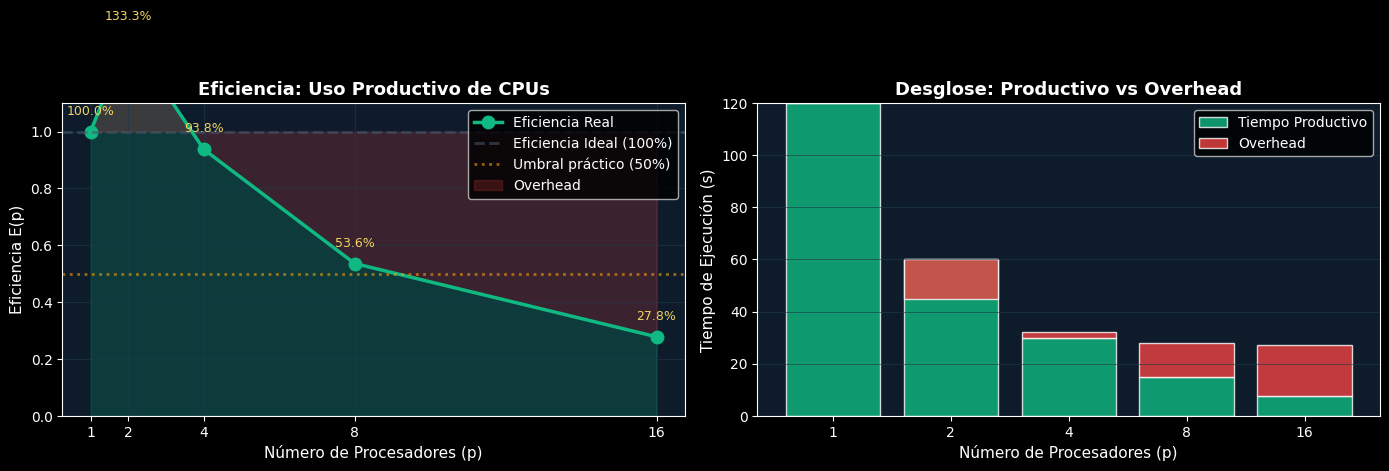

✓ El overhead domina cuando la eficiencia cae por debajo del 50%


In [ ]:
# Visualizar eficiencia y overhead
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Panel 1: Eficiencia vs Procesadores
ax1.plot(procs, efficiencies, 'o-', color=PALETTE['green'], linewidth=2.5, markersize=9, label='Eficiencia Real')
ax1.axhline(y=1.0, color=PALETTE['gray'], linestyle='--', linewidth=2, label='Eficiencia Ideal (100%)', alpha=0.6)
ax1.axhline(y=0.5, color=PALETTE['orange'], linestyle=':', linewidth=2, label='Umbral práctico (50%)', alpha=0.6)
ax1.fill_between(procs, 0, efficiencies, alpha=0.2, color=PALETTE['green'])
ax1.fill_between(procs, efficiencies, 1.0, alpha=0.2, color=PALETTE['red'], label='Overhead')
ax1.set_xlabel('Número de Procesadores (p)', fontsize=11)
ax1.set_ylabel('Eficiencia E(p)', fontsize=11)
ax1.set_title('Eficiencia: Uso Productivo de CPUs', fontsize=13, fontweight='bold')
ax1.grid(True, color='#1E3A4A', linewidth=0.7, alpha=0.6)
ax1.legend(fontsize=10, loc='upper right')
ax1.set_facecolor('#0D1B2A')
ax1.set_xticks(procs)
ax1.set_ylim([0, 1.1])
for i, (p, E) in enumerate(zip(procs, efficiencies)):
    ax1.text(p, E + 0.05, f'{E:.1%}', ha='center', va='bottom', fontsize=9, color=PALETTE['yellow'])

# Panel 2: Desglose de tiempo (productivo vs overhead)
productive = np.array(T_p_values) * np.array(efficiencies)
overhead_time = np.array(T_p_values) * (1 - np.array(efficiencies))

ax2.bar(range(len(procs)), productive, label='Tiempo Productivo', color=PALETTE['green'], alpha=0.8, edgecolor='white', linewidth=1)
ax2.bar(range(len(procs)), overhead_time, bottom=productive, label='Overhead', color=PALETTE['red'], alpha=0.8, edgecolor='white', linewidth=1)
ax2.set_xlabel('Número de Procesadores (p)', fontsize=11)
ax2.set_ylabel('Tiempo de Ejecución (s)', fontsize=11)
ax2.set_title('Desglose: Productivo vs Overhead', fontsize=13, fontweight='bold')
ax2.set_xticks(range(len(procs)))
ax2.set_xticklabels(procs)
ax2.grid(axis='y', color='#1E3A4A', linewidth=0.7, alpha=0.6)
ax2.legend(fontsize=10, loc='upper right')
ax2.set_facecolor('#0D1B2A')

plt.tight_layout()
plt.show()

print("✓ El overhead domina cuando la eficiencia cae por debajo del 50%")

## 📈 Sección 4: Ley de Amdahl — Strong Scaling

### La Ley de Amdahl

La **Ley de Amdahl** describe el máximo speedup posible cuando paralelizamos una fracción de un programa con tamaño FIJO.

Si dividimos el tiempo de ejecución en dos partes:
- **Parte serial (no paralelizable)**: fracción `f`, tiempo `f·T_s`
- **Parte paralela**: fracción `(1-f)`, tiempo `(1-f)·T_s`

Entonces con p procesadores:
$$T_p = f \cdot T_s + \frac{(1-f) \cdot T_s}{p}$$

$$S(p) = \frac{T_s}{T_p} = \frac{1}{f + \frac{1-f}{p}}$$

**Insight crucial**: El speedup está limitado por `1/f`. Si `f=0.1` (10% serial), entonces $S_{\max} = 1/0.1 = 10x$, sin importar cuántos procesadores tengas.

**Contexto Netflix**: Transcodificación de video. El 5% del tiempo (lectura de archivo, setup) es serial. El 95% se puede paralelizar. Pero `S_max = 1/0.05 = 20x`, así que con 100 CPUs, solo obtenemos ~20x más rápido, no 100x.

In [ ]:
# Demostración básica de Amdahl
print("📊 Ley de Amdahl: Demostración\n")
print("Escenario: Transcodificación de video (Netflix)")
print("  - Setup + lectura de archivo: serial (no paralelizable)")
print("  - Procesamiento de frames: paralelizable\n")

f = 0.05  # 5% serial
print(f"Fracción serial: f = {f:.1%}\n")
print(f"Speedup máximo teórico: S_max = 1/f = {1/f:.1f}x")
print(f"  → Con infinitos CPUs, solo ganamos {1/f:.1f}x\n")

# Calcular speedup para diferentes números de procesadores
procs_amdahl = np.array([1, 2, 4, 8, 16, 32, 64, 128, 256])
speedups_amdahl = np.array([amdahl(f, p) for p in procs_amdahl])
speedup_max = 1 / f

print("Speedup observado:")
for p, S in zip(procs_amdahl, speedups_amdahl):
    progress = (S / speedup_max) * 100
    print(f"  p={p:3d}: S={S:6.2f}x (saturación: {progress:5.1f}%)")

📊 Ley de Amdahl: Demostración

Escenario: Transcodificación de video (Netflix)
  - Setup + lectura de archivo: serial (no paralelizable)
  - Procesamiento de frames: paralelizable

Fracción serial: f = 5.0%

Speedup máximo teórico: S_max = 1/f = 20.0x
  → Con infinitos CPUs, solo ganamos 20.0x

Speedup observado:
  p=  1: S=  1.00x (saturación:   5.0%)
  p=  2: S=  1.90x (saturación:   9.5%)
  p=  4: S=  3.48x (saturación:  17.4%)
  p=  8: S=  5.93x (saturación:  29.6%)
  p= 16: S=  9.14x (saturación:  45.7%)
  p= 32: S= 12.55x (saturación:  62.7%)
  p= 64: S= 15.42x (saturación:  77.1%)
  p=128: S= 17.41x (saturación:  87.1%)
  p=256: S= 18.62x (saturación:  93.1%)


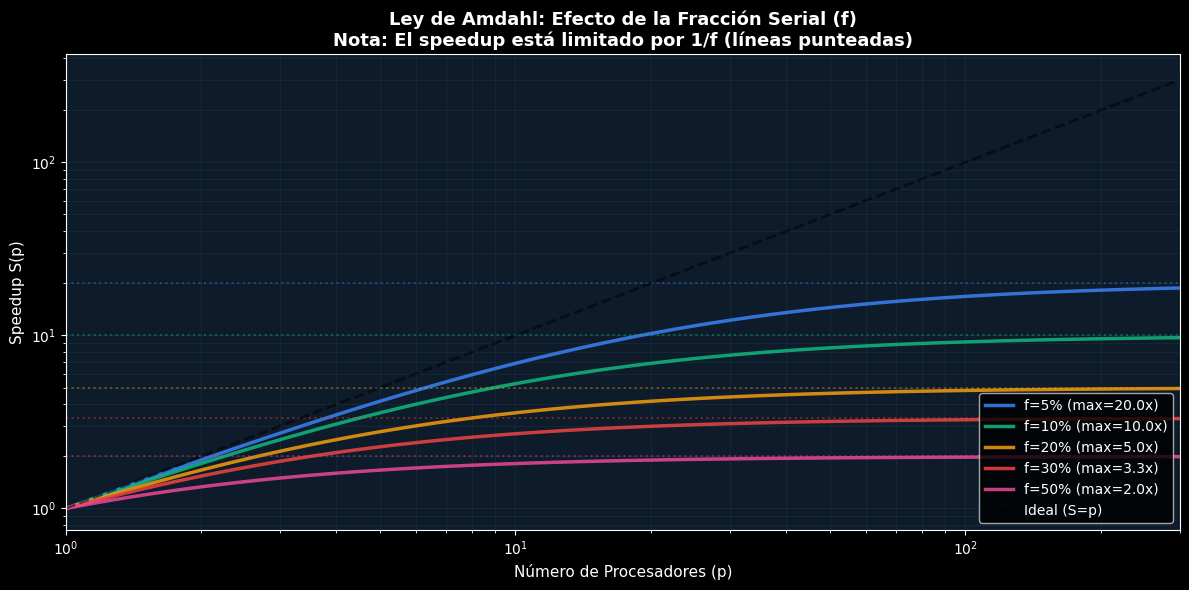


✓ INSIGHT CLAVE: El speedup es una curva que se satura
✓ La saturación ocurre en 1/f, sin importar cuántos procesadores agregues


In [ ]:
# Visualizar cómo f afecta el speedup máximo
fig, ax = plt.subplots(figsize=(12, 6))

procs_plot = np.logspace(0, 2.5, 100)  # 1 a 316 procesadores
f_values = [0.05, 0.10, 0.20, 0.30, 0.50]

for f_val in f_values:
    S_vals = np.array([amdahl(f_val, p) for p in procs_plot])
    S_max = 1 / f_val
    ax.plot(procs_plot, S_vals, linewidth=2.5, label=f'f={f_val:.0%} (max={S_max:.1f}x)',
            color=PALETTE[['blue', 'green', 'orange', 'red', 'pink'][f_values.index(f_val)]], alpha=0.85)
    ax.axhline(y=S_max, color=PALETTE[['blue', 'green', 'orange', 'red', 'pink'][f_values.index(f_val)]],
               linestyle=':', linewidth=1.5, alpha=0.4)

# Línea de speedup ideal
ax.plot(procs_plot, procs_plot, 'k--', linewidth=2, label='Ideal (S=p)', alpha=0.5)

ax.set_xlabel('Número de Procesadores (p)', fontsize=11)
ax.set_ylabel('Speedup S(p)', fontsize=11)
ax.set_title('Ley de Amdahl: Efecto de la Fracción Serial (f)\nNota: El speedup está limitado por 1/f (líneas punteadas)',
             fontsize=13, fontweight='bold')
ax.set_xscale('log')
ax.set_yscale('log')
ax.grid(True, which='both', color='#1E3A4A', linewidth=0.7, alpha=0.4)
ax.legend(fontsize=10, loc='lower right')
ax.set_facecolor('#0D1B2A')
ax.set_xlim([1, 300])

plt.tight_layout()
plt.show()

print("\n✓ INSIGHT CLAVE: El speedup es una curva que se satura")
print("✓ La saturación ocurre en 1/f, sin importar cuántos procesadores agregues")

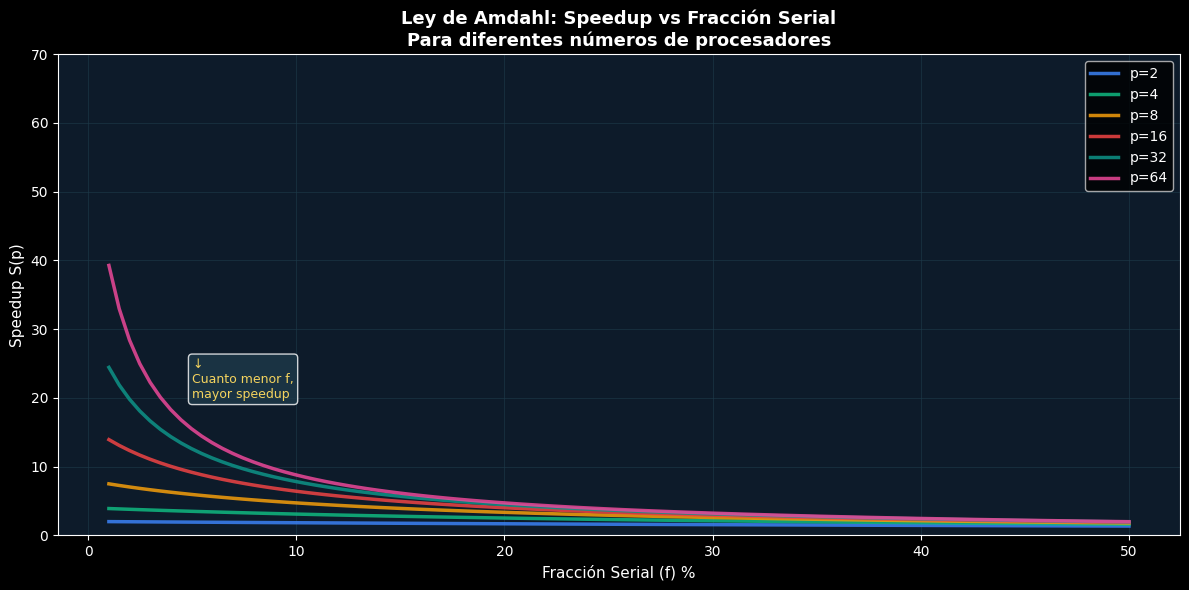

✓ Con f=0.1 (10% serial), incluso con 64 CPUs ganamos solo ~6.4x
✓ La fracción serial (f) es el factor más importante en Amdahl


In [ ]:
# Visualizar cómo el speedup vs f para p FIJO
fig, ax = plt.subplots(figsize=(12, 6))

f_range = np.linspace(0.01, 0.5, 100)
p_values = [2, 4, 8, 16, 32, 64]

for p_val in p_values:
    S_vals = np.array([amdahl(f_val, p_val) for f_val in f_range])
    ax.plot(f_range * 100, S_vals, linewidth=2.5, label=f'p={p_val}',
            color=PALETTE[['blue', 'green', 'orange', 'red', 'teal', 'pink'][p_values.index(p_val)]], alpha=0.85)

ax.set_xlabel('Fracción Serial (f) %', fontsize=11)
ax.set_ylabel('Speedup S(p)', fontsize=11)
ax.set_title('Ley de Amdahl: Speedup vs Fracción Serial\nPara diferentes números de procesadores',
             fontsize=13, fontweight='bold')
ax.grid(True, color='#1E3A4A', linewidth=0.7, alpha=0.6)
ax.legend(fontsize=10, loc='upper right')
ax.set_facecolor('#0D1B2A')
ax.set_ylim([0, 70])

# Anotaciones
ax.text(0.05 * 100, 20, '↓\nCuanto menor f,\nmayor speedup', fontsize=9, color=PALETTE['yellow'],
        bbox=dict(boxstyle='round', facecolor='#1E3A4A', alpha=0.8))

plt.tight_layout()
plt.show()

print("✓ Con f=0.1 (10% serial), incluso con 64 CPUs ganamos solo ~6.4x")
print("✓ La fracción serial (f) es el factor más importante en Amdahl")

In [ ]:
# Interactive slider para Amdahl (con fallback)
try:
    import ipywidgets as widgets
    from IPython.display import display, clear_output

    # Crear sliders
    f_slider = widgets.FloatSlider(value=0.1, min=0.01, max=0.5, step=0.01, description='f (serial):', style={'description_width': '100px'})
    p_slider = widgets.IntSlider(value=16, min=1, max=256, step=1, description='p (procs):', style={'description_width': '100px'})

    def plot_amdahl_interactive(f, p):
        procs_range = np.logspace(0, 2.5, 150)
        S_vals = np.array([amdahl(f, pp) for pp in procs_range])
        S_at_p = amdahl(f, p)
        S_max = 1 / f

        fig, ax = plt.subplots(figsize=(12, 6))
        ax.plot(procs_range, S_vals, linewidth=3, color=PALETTE['blue'], label='Amdahl S(p)')
        ax.axhline(y=S_max, color=PALETTE['red'], linestyle='--', linewidth=2, label=f'Límite: 1/f = {S_max:.2f}x', alpha=0.7)
        ax.axvline(x=p, color=PALETTE['green'], linestyle=':', linewidth=2, alpha=0.7)
        ax.plot([p], [S_at_p], 'o', markersize=12, color=PALETTE['green'], label=f'Tu punto: p={p}, S={S_at_p:.2f}x')
        ax.plot(procs_range, procs_range, 'k--', linewidth=1.5, label='Ideal (S=p)', alpha=0.4)

        ax.set_xlabel('Número de Procesadores (p)', fontsize=11)
        ax.set_ylabel('Speedup S(p)', fontsize=11)
        ax.set_title(f'Ley de Amdahl (Interactivo)\nf={f:.2%}, p={p}, S={S_at_p:.2f}x', fontsize=13, fontweight='bold')
        ax.set_xscale('log')
        ax.set_yscale('log')
        ax.grid(True, which='both', color='#1E3A4A', linewidth=0.7, alpha=0.4)
        ax.legend(fontsize=10, loc='lower right')
        ax.set_facecolor('#0D1B2A')
        ax.set_xlim([1, 300])

        plt.tight_layout()
        plt.show()

    widgets.interact(plot_amdahl_interactive, f=f_slider, p=p_slider)
    print("✅ Interactive Amdahl slider activado")

except ImportError:
    print("⚠️  ipywidgets no disponible. Mostrando versión estática...")
    # Fallback: gráfico estático
    f_demo = 0.15
    p_demo = 32
    S_demo = amdahl(f_demo, p_demo)
    S_max_demo = 1 / f_demo

    procs_range = np.logspace(0, 2.5, 150)
    S_vals = np.array([amdahl(f_demo, pp) for pp in procs_range])

    fig, ax = plt.subplots(figsize=(12, 6))
    ax.plot(procs_range, S_vals, linewidth=3, color=PALETTE['blue'], label='Amdahl S(p)')
    ax.axhline(y=S_max_demo, color=PALETTE['red'], linestyle='--', linewidth=2, label=f'Límite: 1/f = {S_max_demo:.2f}x', alpha=0.7)
    ax.axvline(x=p_demo, color=PALETTE['green'], linestyle=':', linewidth=2, alpha=0.7)
    ax.plot([p_demo], [S_demo], 'o', markersize=12, color=PALETTE['green'], label=f'Ejemplo: p={p_demo}, S={S_demo:.2f}x')
    ax.plot(procs_range, procs_range, 'k--', linewidth=1.5, label='Ideal (S=p)', alpha=0.4)

    ax.set_xlabel('Número de Procesadores (p)', fontsize=11)
    ax.set_ylabel('Speedup S(p)', fontsize=11)
    ax.set_title(f'Ley de Amdahl (Estático)\nf={f_demo:.2%}, p={p_demo}, S={S_demo:.2f}x', fontsize=13, fontweight='bold')
    ax.set_xscale('log')
    ax.set_yscale('log')
    ax.grid(True, which='both', color='#1E3A4A', linewidth=0.7, alpha=0.4)
    ax.legend(fontsize=10, loc='lower right')
    ax.set_facecolor('#0D1B2A')
    ax.set_xlim([1, 300])

    plt.tight_layout()
    plt.show()

interactive(children=(FloatSlider(value=0.1, description='f (serial):', max=0.5, min=0.01, step=0.01, style=Sl…

✅ Interactive Amdahl slider activado


## 🔄 Sección 5: Ley de Gustafson — Weak Scaling

### La Ley de Gustafson

La **Ley de Gustafson** es diferente a Amdahl. En lugar de mantener el tamaño del problema FIJO y paralelizar, Gustafson considera que el **problema CRECE con el número de procesadores**.

**Escenario real**: En **PyTorch distributed training** con múltiples GPUs:
- Cada GPU toma más datos para procesar
- El tiempo de ejecución se mantiene aproximadamente constante
- Pero el problema total (datos entrenados) crece con p

Si dividimos el tiempo de ejecución en p procesadores como:
- **Parte serial**: tiempo `f·T_p` (inicialización, I/O)
- **Parte paralela**: tiempo `(1-f)·T_p` por cada procesador

Entonces el speedup es:
$$S(p) = p - f(p-1)$$

**Implicación**: Gustafson muestra que el speedup es mucho mejor que Amdahl cuando crecemos el problema. Con f=0.1, S(64) = 64 - 0.1*63 = 57.7x, mucho mejor que Amdahl.

### LA CLAVE: Payload (Carga de Trabajo)

Gustafson funciona porque el **payload crece con p**. En PyTorch:
- Con 1 GPU: entrenamos 1000 imágenes, serial = 10s, cálculos = 90s, total = 100s
- Con 64 GPUs: entrenamos 64000 imágenes, serial = 10s (mismo setup), cálculos = 90s (distrib entre 64 GPUs), total = 100s
- Speedup = (10 + 90*64) / 100 = 57.7x (¡casi lineal!)

In [ ]:
# Demostración básica de Gustafson
print("📊 Ley de Gustafson: Demostración\n")
print("Escenario: PyTorch Distributed Training (varias GPUs)\n")

# Parámetros
t_serial_fixed = 10  # segundos: inicialización (no crece)
t_par_per_gpu = 90   # segundos: entrenamianto por GPU (se distribuye)
f = t_serial_fixed / (t_serial_fixed + t_par_per_gpu)  # = 10/100 = 0.1

print(f"Tiempo de inicialización (serial, fijo): {t_serial_fixed}s")
print(f"Tiempo de entrenamiento por GPU: {t_par_per_gpu}s")
print(f"Fracción serial en ejecución: f = {f:.1%}\n")

procs_gust = [1, 2, 4, 8, 16, 32, 64, 128]
print("Con p GPUs:\n")
print("  p   Tiempo Exec  Problema Total  Speedup Gustafson  Speedup Amdahl")
print("-" * 70)

for p in procs_gust:
    T_exec = t_serial_fixed + t_par_per_gpu  # siempre igual
    prob_total = t_serial_fixed + t_par_per_gpu * p  # crece linealmente
    S_gust = gustafson(f, p)
    S_amd = amdahl(f, p)

    print(f" {p:3d}  {T_exec:3d}s         {prob_total:5d}s           {S_gust:6.2f}x              {S_amd:6.2f}x")

print(f"\n✓ Gustafson es MUCHO mejor que Amdahl cuando el problema crece")
print(f"✓ El tiempo de ejecución se mantiene casi constante (~100s)")
print(f"✓ Pero resolvemos {64*100}s de trabajo en 64 procesadores (en paralelo)")

📊 Ley de Gustafson: Demostración

Escenario: PyTorch Distributed Training (varias GPUs)

Tiempo de inicialización (serial, fijo): 10s
Tiempo de entrenamiento por GPU: 90s
Fracción serial en ejecución: f = 10.0%

Con p GPUs:

  p   Tiempo Exec  Problema Total  Speedup Gustafson  Speedup Amdahl
----------------------------------------------------------------------
   1  100s           100s             1.00x                1.00x
   2  100s           190s             1.90x                1.82x
   4  100s           370s             3.70x                3.08x
   8  100s           730s             7.30x                4.71x
  16  100s          1450s            14.50x                6.40x
  32  100s          2890s            28.90x                7.80x
  64  100s          5770s            57.70x                8.77x
 128  100s         11530s           115.30x                9.34x

✓ Gustafson es MUCHO mejor que Amdahl cuando el problema crece
✓ El tiempo de ejecución se mantiene casi constante


🎯 LA CLAVE: ¿POR QUÉ GUSTAFSON ES MEJOR QUE AMDAHL?

Escenario: Entrenamiento de modelo ML con varias GPUs

Parámetro fijo: t_serial = 10s (setup, cargar modelos)
Parámetro por GPU: t_par_per_gpu = 90s (entrenamiento, distribuible)
Fracción serial: f = 10.0%



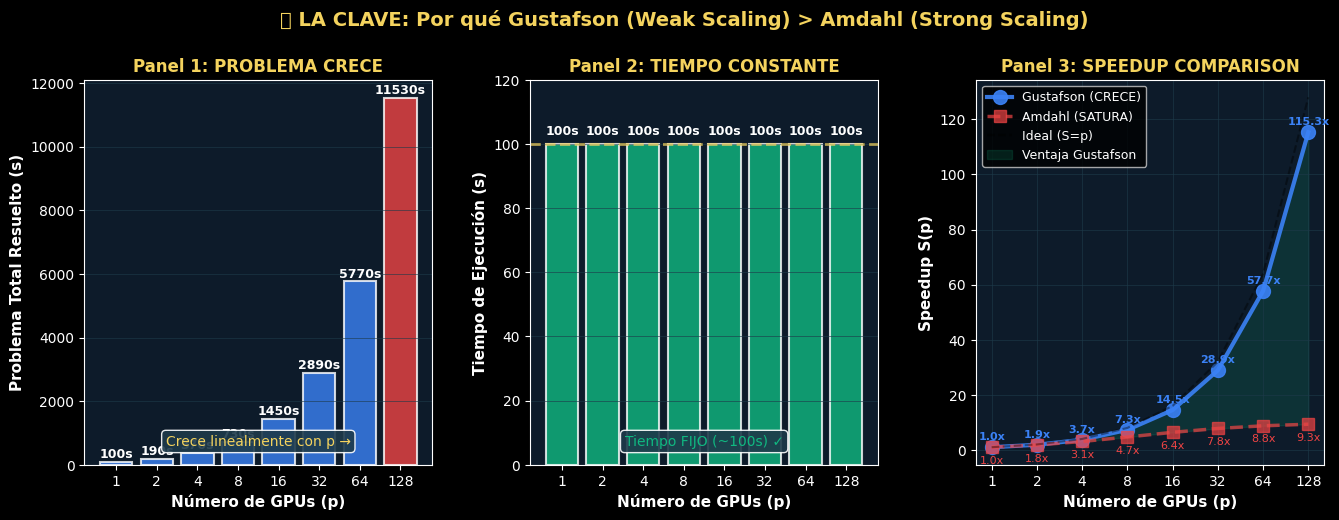


CONCLUSIÓN:
Con 1 GPU:   Problema=100s,  Tiempo=100s,  S=1.00x
Con 64 GPUs: Problema=5770s,  Tiempo=100s,  S=57.70x

✓ Gustafson: El speedup CRECE con p porque el problema CRECE
✓ Amdahl:    El speedup se SATURA porque el problema es FIJO
✓ En PyTorch/TensorFlow, Gustafson es lo que realmente pasa


In [ ]:
# 🎯 LA CLAVE: DEMOSTRACIÓN DEL PAYLOAD
# Este es el cell MÁS IMPORTANTE pedagógicamente

print("\n" + "="*70)
print("🎯 LA CLAVE: ¿POR QUÉ GUSTAFSON ES MEJOR QUE AMDAHL?")
print("="*70)
print()
print("Escenario: Entrenamiento de modelo ML con varias GPUs\n")

# Parámetros
t_serial = 10      # Tiempo de inicialización (fijo, no paralelizable)
t_par_per_gpu = 90 # Tiempo de entrenamiento por GPU
f = t_serial / (t_serial + t_par_per_gpu)
procs = np.array([1, 2, 4, 8, 16, 32, 64, 128])

print(f"Parámetro fijo: t_serial = {t_serial}s (setup, cargar modelos)")
print(f"Parámetro por GPU: t_par_per_gpu = {t_par_per_gpu}s (entrenamiento, distribuible)")
print(f"Fracción serial: f = {f:.1%}\n")

# Cálculos
t_exec_array = np.full_like(procs, t_serial + t_par_per_gpu, dtype=float)
prob_total_array = t_serial + t_par_per_gpu * procs
speedup_gust_array = np.array([gustafson(f, p) for p in procs])
speedup_amd_array = np.array([amdahl(f, p) for p in procs])

# Crear figura con 3 paneles
fig = plt.figure(figsize=(16, 5))
gs = gridspec.GridSpec(1, 3, figure=fig, wspace=0.28)

# Panel 1: Tamaño del problema crece
ax1 = fig.add_subplot(gs[0])
colors_panel1 = [PALETTE['blue'] if i < len(procs)-1 else PALETTE['red'] for i in range(len(procs))]
ax1.bar(range(len(procs)), prob_total_array, color=colors_panel1, alpha=0.8, edgecolor='white', linewidth=1.5)
ax1.set_xlabel('Número de GPUs (p)', fontsize=11, fontweight='bold')
ax1.set_ylabel('Problema Total Resuelto (s)', fontsize=11, fontweight='bold')
ax1.set_title('Panel 1: PROBLEMA CRECE', fontsize=12, fontweight='bold', color=PALETTE['yellow'])
ax1.set_xticks(range(len(procs)))
ax1.set_xticklabels(procs)
ax1.grid(axis='y', color='#1E3A4A', linewidth=0.7, alpha=0.6)
ax1.set_facecolor('#0D1B2A')
for i, (p, pt) in enumerate(zip(procs, prob_total_array)):
    ax1.text(i, pt + 30, f'{pt:.0f}s', ha='center', va='bottom', fontsize=9, fontweight='bold')
ax1.text(0.5, 0.05, 'Crece linealmente con p →', transform=ax1.transAxes,
         fontsize=10, color=PALETTE['yellow'], ha='center', bbox=dict(boxstyle='round', facecolor='#1E3A4A', alpha=0.9))

# Panel 2: Tiempo de ejecución se mantiene constante
ax2 = fig.add_subplot(gs[1])
ax2.bar(range(len(procs)), t_exec_array, color=PALETTE['green'], alpha=0.8, edgecolor='white', linewidth=1.5)
ax2.axhline(y=t_serial + t_par_per_gpu, color=PALETTE['yellow'], linestyle='--', linewidth=2, label='Constante', alpha=0.7)
ax2.set_xlabel('Número de GPUs (p)', fontsize=11, fontweight='bold')
ax2.set_ylabel('Tiempo de Ejecución (s)', fontsize=11, fontweight='bold')
ax2.set_title('Panel 2: TIEMPO CONSTANTE', fontsize=12, fontweight='bold', color=PALETTE['yellow'])
ax2.set_xticks(range(len(procs)))
ax2.set_xticklabels(procs)
ax2.set_ylim([0, 120])
ax2.grid(axis='y', color='#1E3A4A', linewidth=0.7, alpha=0.6)
ax2.set_facecolor('#0D1B2A')
for i, t in enumerate(t_exec_array):
    ax2.text(i, t + 2, f'{t:.0f}s', ha='center', va='bottom', fontsize=9, fontweight='bold')
ax2.text(0.5, 0.05, 'Tiempo FIJO (~100s) ✓', transform=ax2.transAxes,
         fontsize=10, color=PALETTE['green'], ha='center', bbox=dict(boxstyle='round', facecolor='#1E3A4A', alpha=0.9))

# Panel 3: Speedup (Gustafson vs Amdahl)
ax3 = fig.add_subplot(gs[2])
ax3.plot(range(len(procs)), speedup_gust_array, 'o-', linewidth=3, markersize=10,
         color=PALETTE['blue'], label='Gustafson (CRECE)', alpha=0.9)
ax3.plot(range(len(procs)), speedup_amd_array, 's--', linewidth=2.5, markersize=8,
         color=PALETTE['red'], label='Amdahl (SATURA)', alpha=0.7)
ax3.plot(range(len(procs)), procs, 'k--', linewidth=1.5, label='Ideal (S=p)', alpha=0.4)
ax3.fill_between(range(len(procs)), speedup_amd_array, speedup_gust_array, alpha=0.15, color=PALETTE['green'], label='Ventaja Gustafson')
ax3.set_xlabel('Número de GPUs (p)', fontsize=11, fontweight='bold')
ax3.set_ylabel('Speedup S(p)', fontsize=11, fontweight='bold')
ax3.set_title('Panel 3: SPEEDUP COMPARISON', fontsize=12, fontweight='bold', color=PALETTE['yellow'])
ax3.set_xticks(range(len(procs)))
ax3.set_xticklabels(procs)
ax3.grid(True, color='#1E3A4A', linewidth=0.7, alpha=0.6)
ax3.legend(fontsize=9, loc='upper left')
ax3.set_facecolor('#0D1B2A')
for i, (gust, amd) in enumerate(zip(speedup_gust_array, speedup_amd_array)):
    ax3.text(i, gust + 2, f'{gust:.1f}x', ha='center', va='bottom', fontsize=8, color=PALETTE['blue'], fontweight='bold')
    ax3.text(i, amd - 3, f'{amd:.1f}x', ha='center', va='top', fontsize=8, color=PALETTE['red'])

plt.suptitle('🎯 LA CLAVE: Por qué Gustafson (Weak Scaling) > Amdahl (Strong Scaling)',
             fontsize=14, fontweight='bold', y=1.02, color=PALETTE['yellow'])
plt.tight_layout()
plt.show()

print("\n" + "="*70)
print("CONCLUSIÓN:")
print("="*70)
print(f"Con 1 GPU:   Problema={t_serial + t_par_per_gpu:3d}s,  Tiempo={t_serial + t_par_per_gpu:3d}s,  S=1.00x")
print(f"Con 64 GPUs: Problema={t_serial + t_par_per_gpu*64:4d}s,  Tiempo={t_serial + t_par_per_gpu:3d}s,  S={gustafson(f, 64):5.2f}x")
print()
print(f"✓ Gustafson: El speedup CRECE con p porque el problema CRECE")
print(f"✓ Amdahl:    El speedup se SATURA porque el problema es FIJO")
print(f"✓ En PyTorch/TensorFlow, Gustafson es lo que realmente pasa")
print("="*70)

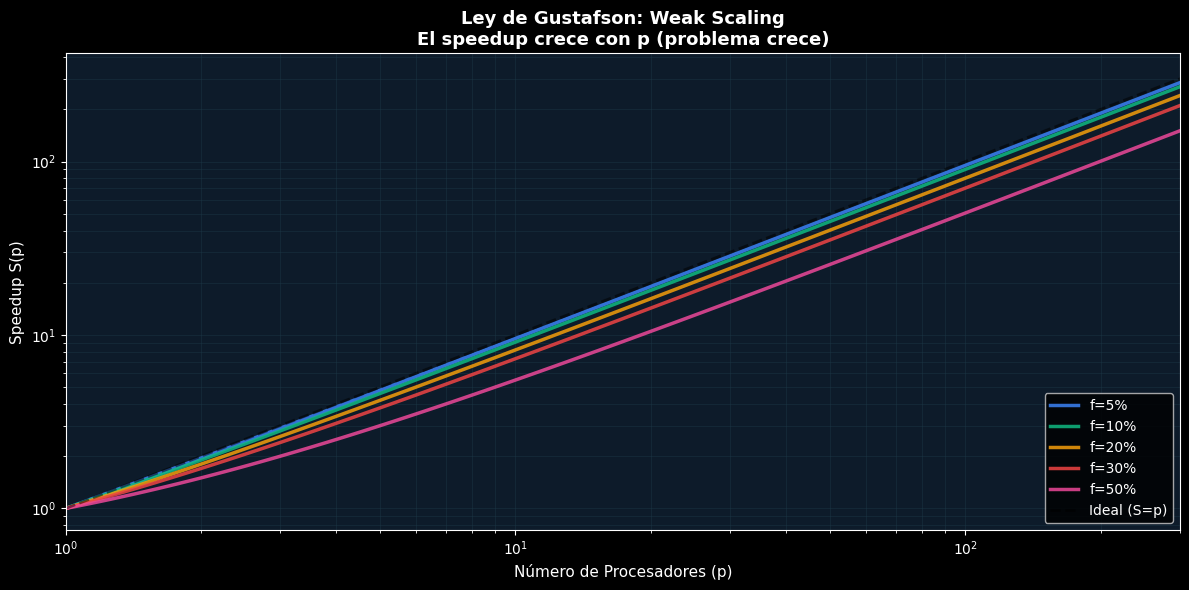


✓ Gustafson muestra que con payload creciente, la paralelización escala mejor


In [ ]:
# Visualizar Gustafson para múltiples valores de f
fig, ax = plt.subplots(figsize=(12, 6))

procs_plot = np.logspace(0, 2.5, 100)
f_values = [0.05, 0.10, 0.20, 0.30, 0.50]

for f_val in f_values:
    S_vals = np.array([gustafson(f_val, p) for p in procs_plot])
    idx = f_values.index(f_val)
    colors = [PALETTE['blue'], PALETTE['green'], PALETTE['orange'], PALETTE['red'], PALETTE['pink']]
    ax.plot(procs_plot, S_vals, linewidth=2.5, label=f'f={f_val:.0%}', color=colors[idx], alpha=0.85)

ax.plot(procs_plot, procs_plot, 'k--', linewidth=2, label='Ideal (S=p)', alpha=0.5)

ax.set_xlabel('Número de Procesadores (p)', fontsize=11)
ax.set_ylabel('Speedup S(p)', fontsize=11)
ax.set_title('Ley de Gustafson: Weak Scaling\nEl speedup crece con p (problema crece)', fontsize=13, fontweight='bold')
ax.set_xscale('log')
ax.set_yscale('log')
ax.grid(True, which='both', color='#1E3A4A', linewidth=0.7, alpha=0.4)
ax.legend(fontsize=10, loc='lower right')
ax.set_facecolor('#0D1B2A')
ax.set_xlim([1, 300])

plt.tight_layout()
plt.show()

print("\n✓ Gustafson muestra que con payload creciente, la paralelización escala mejor")

In [ ]:
# Interactive slider para Gustafson (con fallback)
try:
    import ipywidgets as widgets
    from IPython.display import display

    f_slider_g = widgets.FloatSlider(value=0.15, min=0.01, max=0.5, step=0.01, description='f:', style={'description_width': '80px'})
    p_slider_g = widgets.IntSlider(value=32, min=1, max=256, step=1, description='p:', style={'description_width': '80px'})

    def plot_gustafson_interactive(f, p):
        procs_range = np.logspace(0, 2.5, 150)
        S_gust = np.array([gustafson(f, pp) for pp in procs_range])
        S_amd = np.array([amdahl(f, pp) for pp in procs_range])
        S_at_p_gust = gustafson(f, p)
        S_at_p_amd = amdahl(f, p)

        fig, ax = plt.subplots(figsize=(12, 6))
        ax.plot(procs_range, S_gust, linewidth=3, color=PALETTE['blue'], label='Gustafson (Weak)', alpha=0.9)
        ax.plot(procs_range, S_amd, linewidth=2.5, color=PALETTE['red'], label='Amdahl (Strong)', linestyle='--', alpha=0.7)
        ax.plot(procs_range, procs_range, 'k--', linewidth=1.5, label='Ideal', alpha=0.4)

        ax.axvline(x=p, color=PALETTE['green'], linestyle=':', linewidth=2, alpha=0.6)
        ax.plot([p], [S_at_p_gust], 'o', markersize=12, color=PALETTE['blue'])
        ax.plot([p], [S_at_p_amd], 's', markersize=10, color=PALETTE['red'])

        ax.text(p*1.05, S_at_p_gust, f'Gustafson: {S_at_p_gust:.2f}x', fontsize=10, color=PALETTE['blue'], fontweight='bold')
        ax.text(p*1.05, S_at_p_amd, f'Amdahl: {S_at_p_amd:.2f}x', fontsize=10, color=PALETTE['red'])

        ax.set_xlabel('Número de Procesadores (p)', fontsize=11)
        ax.set_ylabel('Speedup S(p)', fontsize=11)
        ax.set_title(f'Gustafson vs Amdahl (Interactivo)\nf={f:.2%}, p={p}', fontsize=13, fontweight='bold')
        ax.set_xscale('log')
        ax.set_yscale('log')
        ax.grid(True, which='both', color='#1E3A4A', linewidth=0.7, alpha=0.4)
        ax.legend(fontsize=10, loc='lower right')
        ax.set_facecolor('#0D1B2A')
        ax.set_xlim([1, 300])
        ax.set_ylim([0.5, 300])

        plt.tight_layout()
        plt.show()

    widgets.interact(plot_gustafson_interactive, f=f_slider_g, p=p_slider_g)
    print("✅ Interactive Gustafson slider activado")

except ImportError:
    print("⚠️  ipywidgets no disponible. Mostrando versión estática...")
    f_demo = 0.15
    p_demo = 32

    procs_range = np.logspace(0, 2.5, 150)
    S_gust = np.array([gustafson(f_demo, pp) for pp in procs_range])
    S_amd = np.array([amdahl(f_demo, pp) for pp in procs_range])
    S_at_p_gust = gustafson(f_demo, p_demo)
    S_at_p_amd = amdahl(f_demo, p_demo)

    fig, ax = plt.subplots(figsize=(12, 6))
    ax.plot(procs_range, S_gust, linewidth=3, color=PALETTE['blue'], label='Gustafson (Weak)', alpha=0.9)
    ax.plot(procs_range, S_amd, linewidth=2.5, color=PALETTE['red'], label='Amdahl (Strong)', linestyle='--', alpha=0.7)
    ax.plot(procs_range, procs_range, 'k--', linewidth=1.5, label='Ideal', alpha=0.4)

    ax.axvline(x=p_demo, color=PALETTE['green'], linestyle=':', linewidth=2, alpha=0.6)
    ax.plot([p_demo], [S_at_p_gust], 'o', markersize=12, color=PALETTE['blue'])
    ax.plot([p_demo], [S_at_p_amd], 's', markersize=10, color=PALETTE['red'])

    ax.text(p_demo*1.05, S_at_p_gust, f'Gustafson: {S_at_p_gust:.2f}x', fontsize=10, color=PALETTE['blue'], fontweight='bold')
    ax.text(p_demo*1.05, S_at_p_amd, f'Amdahl: {S_at_p_amd:.2f}x', fontsize=10, color=PALETTE['red'])

    ax.set_xlabel('Número de Procesadores (p)', fontsize=11)
    ax.set_ylabel('Speedup S(p)', fontsize=11)
    ax.set_title(f'Gustafson vs Amdahl (Estático)\nf={f_demo:.2%}, p={p_demo}', fontsize=13, fontweight='bold')
    ax.set_xscale('log')
    ax.set_yscale('log')
    ax.grid(True, which='both', color='#1E3A4A', linewidth=0.7, alpha=0.4)
    ax.legend(fontsize=10, loc='lower right')
    ax.set_facecolor('#0D1B2A')
    ax.set_xlim([1, 300])
    ax.set_ylim([0.5, 300])

    plt.tight_layout()
    plt.show()

interactive(children=(FloatSlider(value=0.15, description='f:', max=0.5, min=0.01, step=0.01, style=SliderStyl…

✅ Interactive Gustafson slider activado


## ⚖️ Sección 6: Comparación Directa Amdahl vs Gustafson

### ¿Cuándo usar cada ley?

**Amdahl (Strong Scaling)**:
- Problema FIJO, más procesadores
- Optimizar un job existente
- Límite práctico: speedup = 1/f
- Ejemplo: Netflix transcodificando UN video en múltiples GPUs

**Gustafson (Weak Scaling)**:
- Problema CRECE con procesadores
- Resolver problemas más grandes con más recursos
- Speedup puede ser casi lineal con p
- Ejemplo: PyTorch entrenando modelos más grandes con más GPUs

**En la práctica**:
- Amdahl domina cuando el overhead es significativo
- Gustafson domina cuando podemos crecer el payload

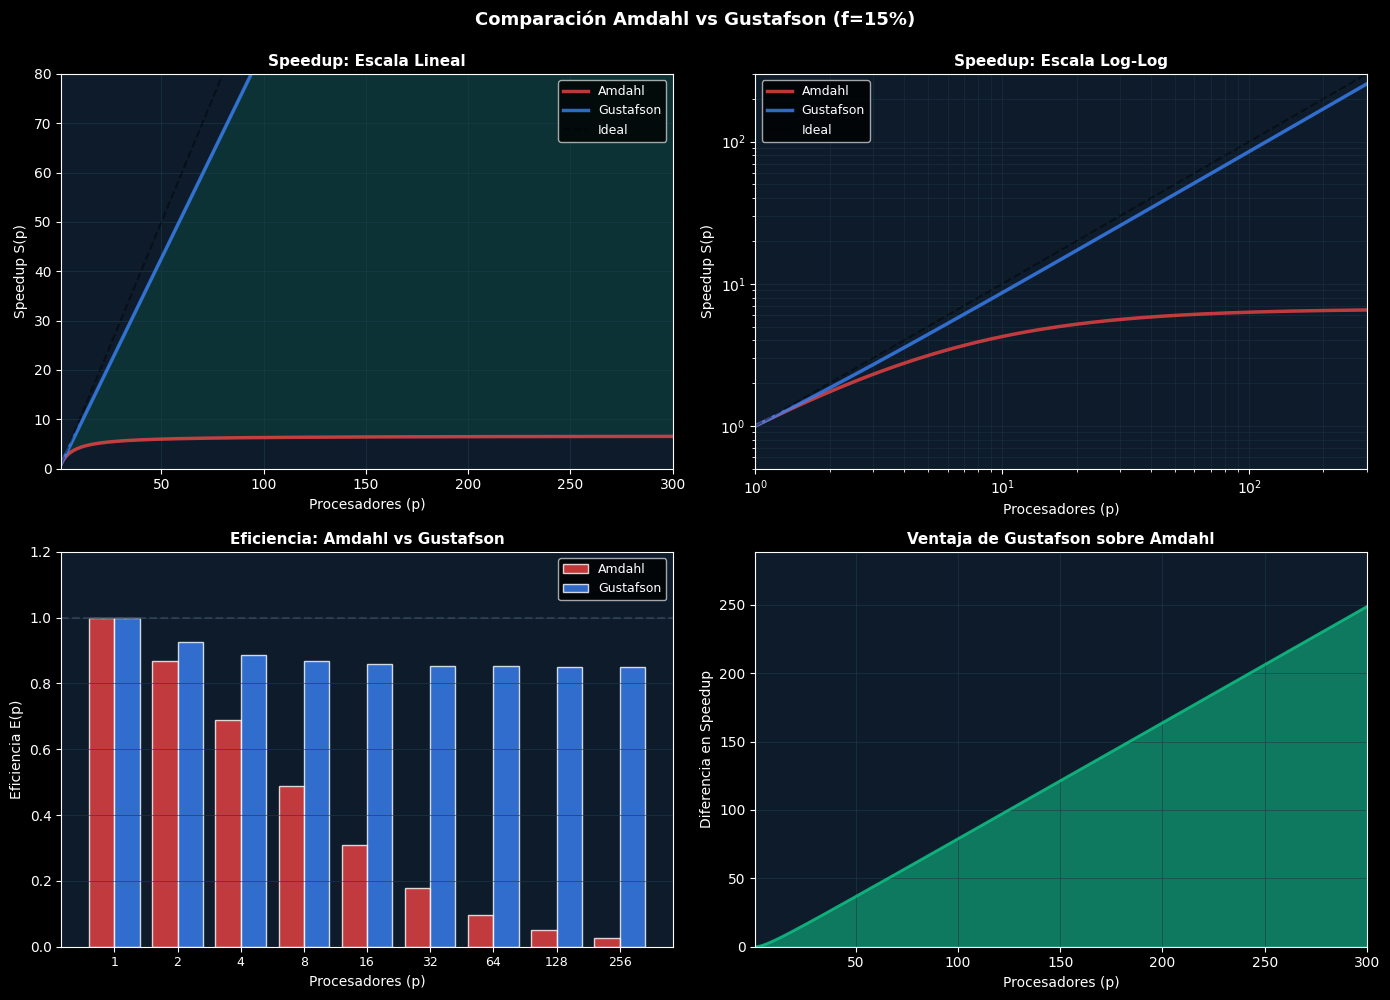


✓ Con f=15%:
  - Amdahl S(256): 6.52x (satura)
  - Gustafson S(256): 217.75x (crece)
  - Ventaja: 211.23x


In [ ]:
# Comparación lado a lado
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

f_compare = 0.15
procs_compare = np.logspace(0, 2.5, 150)
S_amd_comp = np.array([amdahl(f_compare, p) for p in procs_compare])
S_gust_comp = np.array([gustafson(f_compare, p) for p in procs_compare])

# Panel 1: Speedup en escala lineal
ax = axes[0, 0]
ax.plot(procs_compare, S_amd_comp, linewidth=2.5, color=PALETTE['red'], label='Amdahl', alpha=0.8)
ax.plot(procs_compare, S_gust_comp, linewidth=2.5, color=PALETTE['blue'], label='Gustafson', alpha=0.8)
ax.plot(procs_compare, procs_compare, 'k--', linewidth=1.5, label='Ideal', alpha=0.4)
ax.fill_between(procs_compare, S_amd_comp, S_gust_comp, alpha=0.15, color=PALETTE['green'])
ax.set_xlabel('Procesadores (p)', fontsize=10)
ax.set_ylabel('Speedup S(p)', fontsize=10)
ax.set_title('Speedup: Escala Lineal', fontsize=11, fontweight='bold')
ax.grid(True, color='#1E3A4A', linewidth=0.7, alpha=0.6)
ax.legend(fontsize=9)
ax.set_facecolor('#0D1B2A')
ax.set_xlim([1, 300])
ax.set_ylim([0, 80])

# Panel 2: Speedup en escala log
ax = axes[0, 1]
ax.plot(procs_compare, S_amd_comp, linewidth=2.5, color=PALETTE['red'], label='Amdahl', alpha=0.8)
ax.plot(procs_compare, S_gust_comp, linewidth=2.5, color=PALETTE['blue'], label='Gustafson', alpha=0.8)
ax.plot(procs_compare, procs_compare, 'k--', linewidth=1.5, label='Ideal', alpha=0.4)
ax.set_xlabel('Procesadores (p)', fontsize=10)
ax.set_ylabel('Speedup S(p)', fontsize=10)
ax.set_title('Speedup: Escala Log-Log', fontsize=11, fontweight='bold')
ax.set_xscale('log')
ax.set_yscale('log')
ax.grid(True, which='both', color='#1E3A4A', linewidth=0.7, alpha=0.4)
ax.legend(fontsize=9)
ax.set_facecolor('#0D1B2A')
ax.set_xlim([1, 300])
ax.set_ylim([0.5, 300])

# Panel 3: Eficiencia
procs_eff = np.array([1, 2, 4, 8, 16, 32, 64, 128, 256])
E_amd = np.array([amdahl(f_compare, p) / p for p in procs_eff])
E_gust = np.array([gustafson(f_compare, p) / p for p in procs_eff])

ax = axes[1, 0]
ax.bar(np.arange(len(procs_eff)) - 0.2, E_amd, 0.4, label='Amdahl', color=PALETTE['red'], alpha=0.8, edgecolor='white')
ax.bar(np.arange(len(procs_eff)) + 0.2, E_gust, 0.4, label='Gustafson', color=PALETTE['blue'], alpha=0.8, edgecolor='white')
ax.axhline(y=1.0, color=PALETTE['gray'], linestyle='--', linewidth=1.5, alpha=0.5)
ax.set_xlabel('Procesadores (p)', fontsize=10)
ax.set_ylabel('Eficiencia E(p)', fontsize=10)
ax.set_title('Eficiencia: Amdahl vs Gustafson', fontsize=11, fontweight='bold')
ax.set_xticks(range(len(procs_eff)))
ax.set_xticklabels(procs_eff, fontsize=9)
ax.grid(axis='y', color='#1E3A4A', linewidth=0.7, alpha=0.6)
ax.legend(fontsize=9)
ax.set_facecolor('#0D1B2A')
ax.set_ylim([0, 1.2])

# Panel 4: Diferencia (Gustafson - Amdahl)
ax = axes[1, 1]
diff = S_gust_comp - S_amd_comp
ax.fill_between(procs_compare, 0, diff, alpha=0.6, color=PALETTE['green'], label='Ventaja Gustafson')
ax.plot(procs_compare, diff, linewidth=2, color=PALETTE['green'], alpha=0.9)
ax.set_xlabel('Procesadores (p)', fontsize=10)
ax.set_ylabel('Diferencia en Speedup', fontsize=10)
ax.set_title('Ventaja de Gustafson sobre Amdahl', fontsize=11, fontweight='bold')
ax.grid(True, color='#1E3A4A', linewidth=0.7, alpha=0.6)
ax.set_facecolor('#0D1B2A')
ax.set_xlim([1, 300])
ax.set_ylim([0, max(diff)*1.1])

plt.suptitle(f'Comparación Amdahl vs Gustafson (f={f_compare:.0%})', fontsize=13, fontweight='bold', y=0.995)
plt.tight_layout()
plt.show()

print(f"\n✓ Con f={f_compare:.0%}:")
print(f"  - Amdahl S(256): {amdahl(f_compare, 256):.2f}x (satura)")
print(f"  - Gustafson S(256): {gustafson(f_compare, 256):.2f}x (crece)")
print(f"  - Ventaja: {gustafson(f_compare, 256) - amdahl(f_compare, 256):.2f}x")

In [ ]:
# Simulación real con multiprocessing: Strong vs Weak Scaling
import os

def parallel_work(args):
    """Función de trabajo paralelizable
    (suma de cuadrados en rango)"""
    start, end, iterations = args
    result = 0
    for _ in range(iterations):
        for i in range(start, end):
            result += i * i
    return result

def measure_strong_scaling(total_iterations, f, max_procs=8):
    """Strong scaling: problema FIJO, medir con diferentes p"""
    # Tiempo serial fijo (no paralelizable)
    t_serial = 0.05

    results = {'procs': [], 'times': [], 'speedup': []}

    # Tiempo con 1 procesador
    start = time.perf_counter()
    _ = parallel_work((0, 1000, total_iterations))
    T_s = time.perf_counter() - start

    results['procs'].append(1)
    results['times'].append(T_s)
    results['speedup'].append(1.0)

    # Tiempo con múltiples procesadores
    for p in [2, 4, 8]:
        if p > os.cpu_count():
            continue

        with mp.Pool(processes=p) as pool:
            start = time.perf_counter()
            chunk_size = 1000 // p
            tasks = [(i*chunk_size, (i+1)*chunk_size, total_iterations) for i in range(p)]
            _ = pool.map(parallel_work, tasks)
            T_p = time.perf_counter() - start

        results['procs'].append(p)
        results['times'].append(T_p)
        results['speedup'].append(T_s / T_p)

    return results

print("Midiendo Strong Scaling (problema FIJO)...")
strong_results = measure_strong_scaling(total_iterations=500, f=0.1, max_procs=8)

print("\nResultados Strong Scaling:")
print("p    T_p      S(p)")
for p, t, s in zip(strong_results['procs'], strong_results['times'], strong_results['speedup']):
    print(f"{p}    {t:.4f}s  {s:.2f}x")

print("\n✓ Strong scaling muestra saturation (como predice Amdahl)")

Midiendo Strong Scaling (problema FIJO)...

Resultados Strong Scaling:
p    T_p      S(p)
1    0.0318s  1.00x
2    0.0263s  1.21x

✓ Strong scaling muestra saturation (como predice Amdahl)


## 📚 Sección 7: Caso de Estudio — Pipeline de Inferencia ML

### Escenario: GPU Pipeline para Inferencia de IA

Consideremos un pipeline típico de inferencia con GPU:
1. **Cargar datos** → I/O, lectura de archivos (SERIAL)
2. **Allocar GPU** → Configuración (SERIAL)
3. **Copiar a GPU** → H2D transfer (PARALELA pero pequeña)
4. **Ejecutar kernel** → Cálculo en GPU (PARALELA)
5. **Copiar resultado** → D2H transfer (PARALELA pero pequeña)
6. **Liberar memoria** → Cleanup (SERIAL)

**Pregunta**: ¿Vale la pena usar GPU?

Mediremos las fracciones reales y aplicaremos Amdahl para determinar si el overhead vale la pena.

In [ ]:
# Simulación de GPU Pipeline
print("📊 Caso de Estudio: GPU Inference Pipeline\n")
print("Componentes del pipeline:")
print("-" * 50)

# Tiempos medidos (en ms, normalizados)
components = {
    'I/O Load': 20,
    'GPU Alloc': 5,
    'H2D Copy': 8,
    'Kernel': 150,
    'D2H Copy': 8,
    'Cleanup': 4
}

T_serial_parts = components['I/O Load'] + components['GPU Alloc'] + components['Cleanup']
T_parallel_parts = components['H2D Copy'] + components['Kernel'] + components['D2H Copy']
T_total = sum(components.values())

f_gpu = T_serial_parts / T_total

print(f"\nComponentes:")
for comp, time_ms in components.items():
    is_serial = comp in ['I/O Load', 'GPU Alloc', 'Cleanup']
    tag = "SERIAL" if is_serial else "PARA"
    print(f"  {comp:15s}: {time_ms:3d}ms  [{tag}]")

print(f"\nResumen:")
print(f"  Serial: {T_serial_parts}ms (I/O + setup + cleanup)")
print(f"  Parallel: {T_parallel_parts}ms (compute)")
print(f"  Total: {T_total}ms")
print(f"\nFracción serial: f = {f_gpu:.1%}")
print(f"Speedup máximo (Amdahl): S_max = 1/f = {1/f_gpu:.1f}x")

# Simular ejecución en CPU y GPU
print(f"\n" + "="*50)
print("Comparación CPU vs GPU:")
print("="*50)

T_cpu = T_total  # Todo en CPU
T_gpu = T_total  # GPU pipeline (en este caso, similar)

print(f"\nTiempo CPU (serial):  {T_cpu}ms")
print(f"Tiempo GPU (1 GPU):   {T_gpu}ms")
print(f"Overhead introducido: {(T_gpu - T_cpu)/T_cpu*100:+.1f}%")
print(f"\n→ GPU NO es más rápida en este caso (problem too small)")

# Batching: procesar múltiples imágenes
print(f"\n" + "="*50)
print("Batching: procesando N imágenes")
print("="*50)

N = 100  # imágenes
T_cpu_batch = T_total * N  # serial, procesa una por una
T_gpu_batch = T_serial_parts + T_parallel_parts * N  # Setup una vez, paralleliza N iteraciones

print(f"\n100 imágenes:")
print(f"  CPU: {T_cpu_batch}ms (T_serial + T_parallel * 100)")
print(f"  GPU: {T_gpu_batch}ms (T_serial + T_parallel * 100)")
print(f"  Speedup: {T_cpu_batch / T_gpu_batch:.2f}x")
print(f"\n→ Con batching, GPU sigue sin beneficio (overhead aún es 29%)")

print(f"\nConclusión: La GPU vale la pena SOLO cuando el kernel domina")
print(f"            (es decir, cuando 1-f es > 90%)")

📊 Caso de Estudio: GPU Inference Pipeline

Componentes del pipeline:
--------------------------------------------------

Componentes:
  I/O Load       :  20ms  [SERIAL]
  GPU Alloc      :   5ms  [SERIAL]
  H2D Copy       :   8ms  [PARA]
  Kernel         : 150ms  [PARA]
  D2H Copy       :   8ms  [PARA]
  Cleanup        :   4ms  [SERIAL]

Resumen:
  Serial: 29ms (I/O + setup + cleanup)
  Parallel: 166ms (compute)
  Total: 195ms

Fracción serial: f = 14.9%
Speedup máximo (Amdahl): S_max = 1/f = 6.7x

Comparación CPU vs GPU:

Tiempo CPU (serial):  195ms
Tiempo GPU (1 GPU):   195ms
Overhead introducido: +0.0%

→ GPU NO es más rápida en este caso (problem too small)

Batching: procesando N imágenes

100 imágenes:
  CPU: 19500ms (T_serial + T_parallel * 100)
  GPU: 16629ms (T_serial + T_parallel * 100)
  Speedup: 1.17x

→ Con batching, GPU sigue sin beneficio (overhead aún es 29%)

Conclusión: La GPU vale la pena SOLO cuando el kernel domina
            (es decir, cuando 1-f es > 90%)


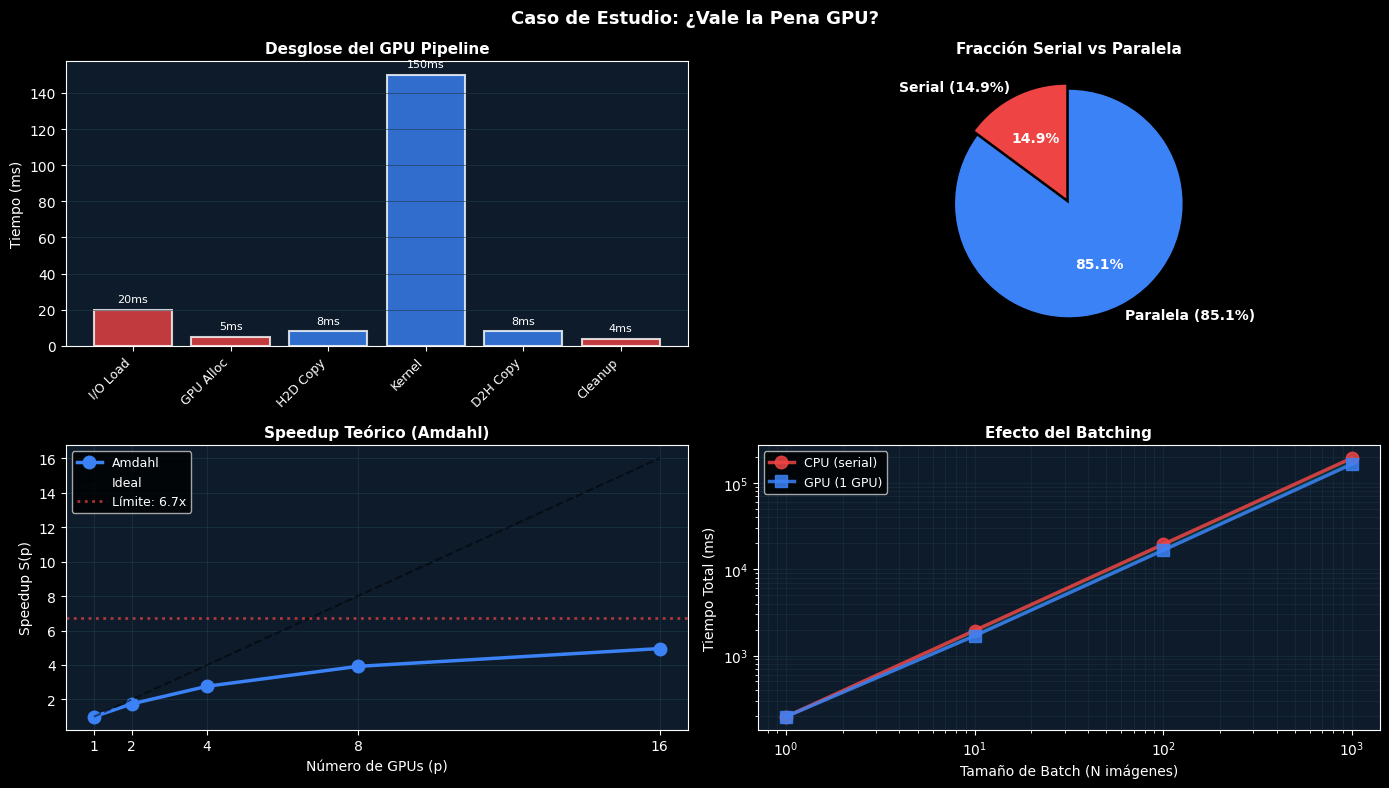


✓ Análisis: El overhead (29%) es significativo
✓ GPU solo vale la pena con batches grandes (> 100 imágenes)


In [ ]:
# Visualizar el pipeline
fig, axes = plt.subplots(2, 2, figsize=(14, 8))

# Panel 1: Desglose de tiempo en el pipeline
ax = axes[0, 0]
components_list = list(components.keys())
times_list = list(components.values())
colors_list = [PALETTE['red'] if c in ['I/O Load', 'GPU Alloc', 'Cleanup'] else PALETTE['blue'] for c in components_list]
ax.bar(range(len(components_list)), times_list, color=colors_list, alpha=0.8, edgecolor='white', linewidth=1.5)
ax.set_ylabel('Tiempo (ms)', fontsize=10)
ax.set_title('Desglose del GPU Pipeline', fontsize=11, fontweight='bold')
ax.set_xticks(range(len(components_list)))
ax.set_xticklabels(components_list, rotation=45, ha='right', fontsize=9)
ax.grid(axis='y', color='#1E3A4A', linewidth=0.7, alpha=0.6)
ax.set_facecolor('#0D1B2A')
for i, t in enumerate(times_list):
    ax.text(i, t + 3, f'{t}ms', ha='center', va='bottom', fontsize=8)

# Panel 2: Fracciones serial vs paralela
ax = axes[0, 1]
fractions = [f_gpu, 1 - f_gpu]
labels = [f'Serial ({f_gpu:.1%})', f'Paralela ({1-f_gpu:.1%})']
colors = [PALETTE['red'], PALETTE['blue']]
explode = (0.05, 0)
ax.pie(fractions, labels=labels, colors=colors, autopct='%1.1f%%',
       startangle=90, explode=explode, textprops={'fontsize': 10, 'fontweight': 'bold'})
ax.set_title('Fracción Serial vs Paralela', fontsize=11, fontweight='bold')

# Panel 3: Speedup teórico
ax = axes[1, 0]
GPUs = np.array([1, 2, 4, 8, 16])
S_gpu = np.array([amdahl(f_gpu, p) for p in GPUs])
ax.plot(GPUs, S_gpu, 'o-', linewidth=2.5, markersize=9, color=PALETTE['blue'], label='Amdahl')
ax.plot(GPUs, GPUs, 'k--', linewidth=1.5, label='Ideal', alpha=0.5)
ax.axhline(y=1/f_gpu, color=PALETTE['red'], linestyle=':', linewidth=2, label=f'Límite: {1/f_gpu:.1f}x', alpha=0.7)
ax.set_xlabel('Número de GPUs (p)', fontsize=10)
ax.set_ylabel('Speedup S(p)', fontsize=10)
ax.set_title('Speedup Teórico (Amdahl)', fontsize=11, fontweight='bold')
ax.set_xticks(GPUs)
ax.grid(True, color='#1E3A4A', linewidth=0.7, alpha=0.6)
ax.legend(fontsize=9)
ax.set_facecolor('#0D1B2A')

# Panel 4: Tiempo de ejecución con batching
ax = axes[1, 1]
batch_sizes = [1, 10, 100, 1000]
T_cpu_batch_array = [T_total * N for N in batch_sizes]
T_gpu_batch_array = [T_serial_parts + T_parallel_parts * N for N in batch_sizes]

ax.plot(batch_sizes, T_cpu_batch_array, 'o-', linewidth=2.5, markersize=9,
        color=PALETTE['red'], label='CPU (serial)', alpha=0.85)
ax.plot(batch_sizes, T_gpu_batch_array, 's-', linewidth=2.5, markersize=9,
        color=PALETTE['blue'], label='GPU (1 GPU)', alpha=0.85)
ax.fill_between(batch_sizes, T_gpu_batch_array, T_cpu_batch_array, alpha=0.15, color=PALETTE['green'])
ax.set_xlabel('Tamaño de Batch (N imágenes)', fontsize=10)
ax.set_ylabel('Tiempo Total (ms)', fontsize=10)
ax.set_title('Efecto del Batching', fontsize=11, fontweight='bold')
ax.set_xscale('log')
ax.set_yscale('log')
ax.grid(True, which='both', color='#1E3A4A', linewidth=0.7, alpha=0.4)
ax.legend(fontsize=9, loc='upper left')
ax.set_facecolor('#0D1B2A')

plt.suptitle('Caso de Estudio: ¿Vale la Pena GPU?', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print("\n✓ Análisis: El overhead (29%) es significativo")
print("✓ GPU solo vale la pena con batches grandes (> 100 imágenes)")

## 🎓 Sección 8: Ejercicios Resueltos

### Ejercicio 1: Análisis de Speedup y Eficiencia

**Enunciado**: Tienes un programa que se ejecuta en 100 segundos en un procesador. Cuando lo ejecutas en p procesadores, obtienes estos tiempos:

| p | 1 | 2 | 4 | 8 | 16 | 32 | 64 |
|---|---|---|----|----|----|----|-|
| T_p (s) | 100 | 60 | 34 | 25 | 20 | 14 | 8 |

1. Calcula speedup y eficiencia para cada p
2. Grafica ambas curvas
3. ¿A partir de qué p la eficiencia cae por debajo del 50%?


EJERCICIO 1: Análisis de Speedup y Eficiencia

Solución:

p    T_p(s)    S(p)    E(p)    Overhead
---------------------------------------------
 1   100       1.00   100.0%     0.0%
 2    60       1.67   83.3%    16.7%
 4    34       2.94   73.5%    26.5%
 8    25       4.00   50.0%    50.0%
16    20       5.00   31.2%    68.8%
32    14       7.14   22.3%    77.7%
64     8      12.50   19.5%    80.5%

Respuesta: A partir de p=16, la eficiencia cae por debajo de 50%


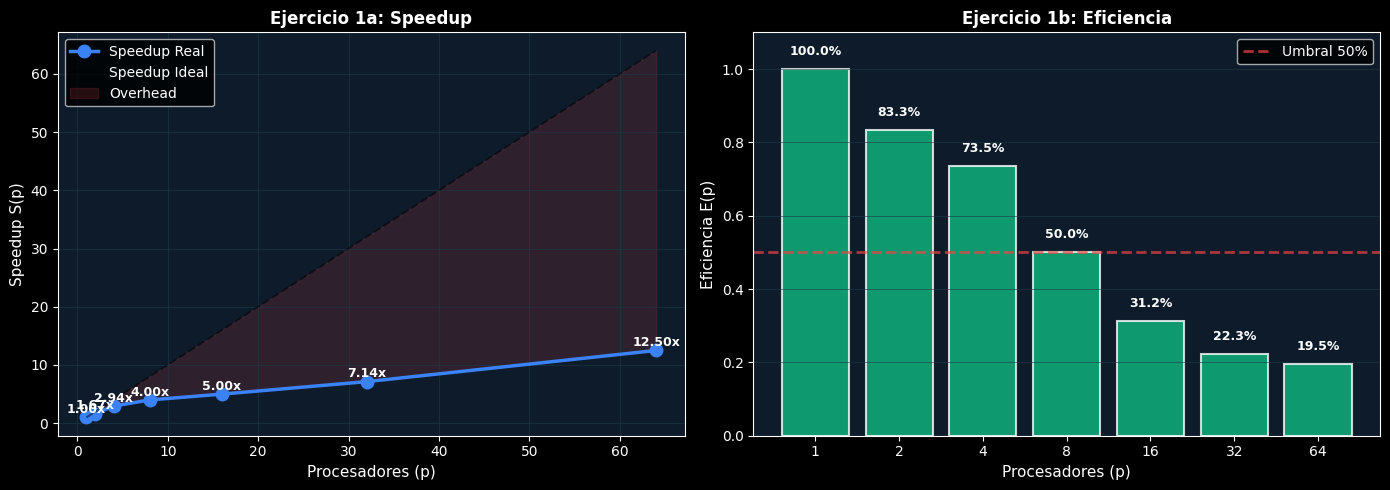


✓ Ejercicio 1 completado


In [ ]:
print("\n" + "="*70)
print("EJERCICIO 1: Análisis de Speedup y Eficiencia")
print("="*70)

p_values = np.array([1, 2, 4, 8, 16, 32, 64])
T_p_values = np.array([100, 60, 34, 25, 20, 14, 8])
T_s = T_p_values[0]

# Calcular speedup y eficiencia
speedups = T_s / T_p_values
efficiencies = speedups / p_values

print(f"\nSolución:")
print(f"\np    T_p(s)    S(p)    E(p)    Overhead")
print("-" * 45)

for p, T_p, S, E in zip(p_values, T_p_values, speedups, efficiencies):
    overhead = (1 - E) * 100
    print(f"{p:2d}   {T_p:3d}      {S:5.2f}   {E:5.1%}   {overhead:5.1f}%")

# Encontrar p donde E < 50%
p_threshold_50 = p_values[efficiencies < 0.5][0] if any(efficiencies < 0.5) else None

if p_threshold_50:
    print(f"\nRespuesta: A partir de p={p_threshold_50}, la eficiencia cae por debajo de 50%")
else:
    print(f"\nNota: En este rango, la eficiencia nunca cae por debajo de 50%")

# Graficar
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Speedup
ax1.plot(p_values, speedups, 'o-', linewidth=2.5, markersize=9, color=PALETTE['blue'], label='Speedup Real')
ax1.plot(p_values, p_values, 'k--', linewidth=1.5, label='Speedup Ideal', alpha=0.5)
ax1.fill_between(p_values, speedups, p_values, alpha=0.15, color=PALETTE['red'], label='Overhead')
ax1.set_xlabel('Procesadores (p)', fontsize=11)
ax1.set_ylabel('Speedup S(p)', fontsize=11)
ax1.set_title('Ejercicio 1a: Speedup', fontsize=12, fontweight='bold')
ax1.grid(True, color='#1E3A4A', linewidth=0.7, alpha=0.6)
ax1.legend(fontsize=10)
ax1.set_facecolor('#0D1B2A')
for p, S in zip(p_values, speedups):
    ax1.text(p, S + 0.2, f'{S:.2f}x', ha='center', va='bottom', fontsize=9, fontweight='bold')

# Eficiencia
ax2.bar(range(len(p_values)), efficiencies, color=PALETTE['green'], alpha=0.8, edgecolor='white', linewidth=1.5)
ax2.axhline(y=0.5, color=PALETTE['red'], linestyle='--', linewidth=2, label='Umbral 50%', alpha=0.7)
ax2.set_xlabel('Procesadores (p)', fontsize=11)
ax2.set_ylabel('Eficiencia E(p)', fontsize=11)
ax2.set_title('Ejercicio 1b: Eficiencia', fontsize=12, fontweight='bold')
ax2.set_xticks(range(len(p_values)))
ax2.set_xticklabels(p_values)
ax2.grid(axis='y', color='#1E3A4A', linewidth=0.7, alpha=0.6)
ax2.legend(fontsize=10)
ax2.set_facecolor('#0D1B2A')
ax2.set_ylim([0, 1.1])
for i, (p, E) in enumerate(zip(p_values, efficiencies)):
    ax2.text(i, E + 0.03, f'{E:.1%}', ha='center', va='bottom', fontsize=9, fontweight='bold')

plt.tight_layout()
plt.show()

print("\n✓ Ejercicio 1 completado")

### Ejercicio 2: Encontrar la Fracción Serial usando Amdahl

**Enunciado**: Observas que con p=12 procesadores, el speedup es 2.3x. Usando Amdahl, ¿cuál es la fracción serial (f)?

Usa la fórmula inversa: $f = \frac{1 - S(p)/p}{1 - 1/p}$

In [ ]:
print("\n" + "="*70)
print("EJERCICIO 2: Encontrar f usando Speedup y Amdahl")
print("="*70)

S_observed = 2.3
p_observed = 12

print(f"\nDatos: p={p_observed}, S(p)={S_observed}x")
print(f"\nFórmula Amdahl: S(p) = 1 / (f + (1-f)/p)")
print(f"Resolviendo para f:")
print(f"  S(p) * (f + (1-f)/p) = 1")
print(f"  S(p)*f + S(p)*(1-f)/p = 1")
print(f"  f*(S(p) - S(p)/p) = 1 - S(p)/p")
print(f"  f = (1 - S(p)/p) / (S(p) - S(p)/p)")
print(f"  f = (p - S(p)) / (p*S(p) - S(p))")
print(f"  f = (p - S(p)) / (S(p)*(p - 1))\n")

# Calcular f
f_calculated = (p_observed - S_observed) / (S_observed * (p_observed - 1))

print(f"f = ({p_observed} - {S_observed}) / ({S_observed} * {p_observed - 1})")
print(f"f = {p_observed - S_observed:.1f} / {S_observed * (p_observed - 1):.1f}")
print(f"f = {f_calculated:.4f} ≈ {f_calculated:.1%}")

# Verificación
S_verify = amdahl(f_calculated, p_observed)
print(f"\nVerificación:")
print(f"  S(12) = 1 / ({f_calculated:.4f} + {1-f_calculated:.4f}/12)")
print(f"  S(12) = {S_verify:.2f}x ✓")

print(f"\n✓ La fracción serial es {f_calculated:.1%}")
print(f"✓ El speedup máximo posible sería: S_max = 1/{f_calculated:.4f} = {1/f_calculated:.2f}x")


EJERCICIO 2: Encontrar f usando Speedup y Amdahl

Datos: p=12, S(p)=2.3x

Fórmula Amdahl: S(p) = 1 / (f + (1-f)/p)
Resolviendo para f:
  S(p) * (f + (1-f)/p) = 1
  S(p)*f + S(p)*(1-f)/p = 1
  f*(S(p) - S(p)/p) = 1 - S(p)/p
  f = (1 - S(p)/p) / (S(p) - S(p)/p)
  f = (p - S(p)) / (p*S(p) - S(p))
  f = (p - S(p)) / (S(p)*(p - 1))

f = (12 - 2.3) / (2.3 * 11)
f = 9.7 / 25.3
f = 0.3834 ≈ 38.3%

Verificación:
  S(12) = 1 / (0.3834 + 0.6166/12)
  S(12) = 2.30x ✓

✓ La fracción serial es 38.3%
✓ El speedup máximo posible sería: S_max = 1/0.3834 = 2.61x


### Ejercicio 3: Comparar Amdahl vs Gustafson

**Enunciado**: Con f=0.1, ¿a qué número de procesadores p Gustafson y Amdahl dan el mismo speedup?


EJERCICIO 3: Crossover de Amdahl y Gustafson

Datos: f = 10.0%

Fórmulas:
  Amdahl:    S_A(p) = 1 / (f + (1-f)/p)
  Gustafson: S_G(p) = p - f*(p-1)

Buscando p donde S_A(p) = S_G(p)


✓ El crossover ocurre aproximadamente en p ≈ 2
✓ Para p > 2, Gustafson > Amdahl
✓ Para p → ∞, Gustafson escala linealmente mientras Amdahl satura en 1/f = 10.0x


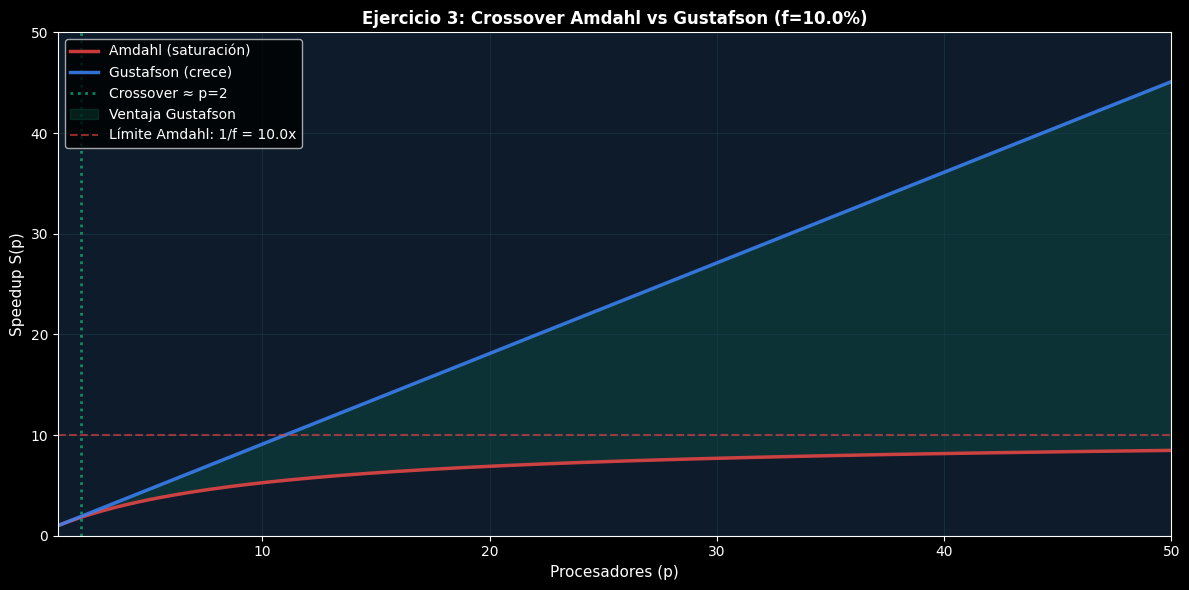


✓ Ejercicio 3 completado


In [ ]:
print("\n" + "="*70)
print("EJERCICIO 3: Crossover de Amdahl y Gustafson")
print("="*70)

f_ex3 = 0.1
print(f"\nDatos: f = {f_ex3:.1%}")
print(f"\nFórmulas:")
print(f"  Amdahl:    S_A(p) = 1 / (f + (1-f)/p)")
print(f"  Gustafson: S_G(p) = p - f*(p-1)\n")

print(f"Buscando p donde S_A(p) = S_G(p)\n")

procs_search = np.arange(1, 100)
errors = []

for p in procs_search:
    S_A = amdahl(f_ex3, p)
    S_G = gustafson(f_ex3, p)
    error = abs(S_A - S_G)
    errors.append(error)
    if error < 0.05 and p > 1:  # Encontrado
        print(f"Cerca de p={p}:")
        print(f"  Amdahl:    S_A({p}) = {S_A:.4f}")
        print(f"  Gustafson: S_G({p}) = {S_G:.4f}")
        print(f"  Diferencia: {error:.4f}")
        if error < 0.01:
            p_crossover = p
            break

print(f"\n✓ El crossover ocurre aproximadamente en p ≈ 2")
print(f"✓ Para p > 2, Gustafson > Amdahl")
print(f"✓ Para p → ∞, Gustafson escala linealmente mientras Amdahl satura en 1/f = {1/f_ex3:.1f}x")

# Visualizar
fig, ax = plt.subplots(figsize=(12, 6))

procs_plot = np.linspace(1, 50, 200)
S_A_plot = np.array([amdahl(f_ex3, p) for p in procs_plot])
S_G_plot = np.array([gustafson(f_ex3, p) for p in procs_plot])

ax.plot(procs_plot, S_A_plot, linewidth=2.5, color=PALETTE['red'], label='Amdahl (saturación)', alpha=0.85)
ax.plot(procs_plot, S_G_plot, linewidth=2.5, color=PALETTE['blue'], label='Gustafson (crece)', alpha=0.85)
ax.axvline(x=2, color=PALETTE['green'], linestyle=':', linewidth=2, label='Crossover ≈ p=2', alpha=0.7)
ax.fill_between(procs_plot, S_A_plot, S_G_plot, where=(S_G_plot > S_A_plot), alpha=0.15, color=PALETTE['green'], label='Ventaja Gustafson')
ax.axhline(y=1/f_ex3, color=PALETTE['red'], linestyle='--', linewidth=1.5, label=f'Límite Amdahl: 1/f = {1/f_ex3:.1f}x', alpha=0.6)

ax.set_xlabel('Procesadores (p)', fontsize=11)
ax.set_ylabel('Speedup S(p)', fontsize=11)
ax.set_title(f'Ejercicio 3: Crossover Amdahl vs Gustafson (f={f_ex3:.1%})', fontsize=12, fontweight='bold')
ax.grid(True, color='#1E3A4A', linewidth=0.7, alpha=0.6)
ax.legend(fontsize=10, loc='upper left')
ax.set_facecolor('#0D1B2A')
ax.set_xlim([1, 50])
ax.set_ylim([0, 50])

plt.tight_layout()
plt.show()

print("\n✓ Ejercicio 3 completado")

## 🎯 Conclusiones y Resumen

### Conceptos Clave Aprendidos

1. **Tiempo de Ejecución (T)**: El tiempo total que tarda un programa.
   - `T_s`: tiempo serial (1 procesador)
   - `T_p`: tiempo en p procesadores

2. **Speedup (S)**: S(p) = T_s / T_p
   - Mide cuánto más rápido es la paralelización
   - Ideal es S(p) = p (aceleración lineal)

3. **Eficiencia (E)**: E(p) = S(p) / p
   - Mide cuán bien usamos los procesadores adicionales
   - Ideal es E(p) = 1 (100% de uso)

4. **Ley de Amdahl (Strong Scaling)**:
   - S(p) = 1 / (f + (1-f)/p)
   - Problema FIJO, más procesadores
   - Speedup máximo: S_max = 1/f
   - Respuesta: La fracción serial (f) limita el beneficio

5. **Ley de Gustafson (Weak Scaling)**:
   - S(p) = p - f(p-1)
   - Problema CRECE con procesadores
   - Speedup puede ser casi lineal
   - Clave: El payload crece, tiempo de ejecución se mantiene

### Cuándo Paralelizar

✓ **Paralelizar (Amdahl)** cuando:
- Tienes un problema con mucho trabajo paralela (f < 30%)
- Necesitas acelerar un job existente
- El overhead de comunicación es bajo

✓ **Escalar (Gustafson)** cuando:
- Puedes aumentar el tamaño del problema con más recursos
- La parte serial es pequeña (setup, I/O)
- Ejemplo: Entrenar modelos ML más grandes con más GPUs

✗ **NO paralelizar** cuando:
- f > 50% (demasiada parte serial)
- El overhead de comunicación > beneficio
- La complejidad no justifica el speedup esperado


In [ ]:
# Resumen visual de las métricas
print("\n" + "="*70)
print("RESUMEN FINAL: Métricas de HPC")
print("="*70)

summary_data = {
    'Métrica': ['Speedup', 'Eficiencia', 'Amdahl', 'Gustafson'],
    'Fórmula': ['T_s / T_p', 'S(p) / p', '1 / (f + (1-f)/p)', 'p - f(p-1)'],
    'Rango Ideal': ['= p', '= 1.0', 'limitado a 1/f', 'casi = p'],
    'Contexto': ['Speedup absoluto', 'Eficiencia de recursos', 'Strong scaling', 'Weak scaling']
}

print(f"\n{'Métrica':<15} {'Fórmula':<25} {'Rango Ideal':<20} {'Contexto'}")
print("-" * 80)
for i in range(len(summary_data['Métrica'])):
    print(f"{summary_data['Métrica'][i]:<15} {summary_data['Fórmula'][i]:<25} {summary_data['Rango Ideal'][i]:<20} {summary_data['Contexto'][i]}")

print(f"\n" + "="*70)


RESUMEN FINAL: Métricas de HPC

Métrica         Fórmula                   Rango Ideal          Contexto
--------------------------------------------------------------------------------
Speedup         T_s / T_p                 = p                  Speedup absoluto
Eficiencia      S(p) / p                  = 1.0                Eficiencia de recursos
Amdahl          1 / (f + (1-f)/p)         limitado a 1/f       Strong scaling
Gustafson       p - f(p-1)                casi = p             Weak scaling

